<table align="center" width="100%">
    <tr>
        <td width="30%">
            <img src="https://miro.medium.com/v2/resize:fit:1400/1*DsOKWVMAbydzfsXI2A9pMQ.png">
        </td>
        <td>
            <div align="center">
                <font color="#89f5cf" size="6">
                    <b>Feature Engineering - 02</b>
                </font>
            </div>
        </td>
    </tr>
</table>

### <font color='sky blue'>**Content**</font>

1. Recap of previous lecture[5 mins]
3. Missing Values [10 mins]
    - Simple Imputer [5 mins]
    - Quiz 1 [5 mins]
6. Outlier Treatment
    - Using Boxplots [5 mins]
    - Using IQR [10 mins]
    - Using Z-score [10 mins]
    - Quiz 2 [5 mins]
    -  <font color="red">**Break [5 mins]**</font>
8. Categorical Encoding & Types [20 mins]
10. Normalisation & Standardization
    - Standard Scaler [10 mins]
    - Minmax Scaler [10 mins]
    - Quiz 4 [5 mins]
10. Practice Question [10 mins]

Total Estimated time: 2 hours

Today, we will discuss the topics of handling missing values in data and discuss strategies for dealing with both categorical and numerical data. Before we dive into these topics, let's begin with a brief review of the concepts we covered in the previous class.

## <font color='sky blue'>**Recap of Previous lecture**  [5 mins] </font>

- As we saw in an example in the last class weight and Fitness are not directly related and Weight and fitness is not directly related.   

- How do we make the best use of the available feature so that I can create some target variable. So we create one feature "BMI" using the existing features which are related to fitness.

- On similar lines, we took a House Loan dataset. We began by analysing individual features like "ApplicantIncome" and "TotalIncome," assessing their impact on "Loan_Status" and discovering potential counterintuitive relationships.

- Employing techniques such as binning and chi-square tests, we gained insights into feature independence.  

- Recognizing the importance of factors like "Loan_Amount" and "Loan_Amount_Term," we created new features, such as "Able_to_pay_EMI," providing a nuanced perspective on loan approval likelihood.



Let's continue from where we left in previous class by reading the updated data that we saved in the previous class.

##### <font color='violet'>Load data and libraries</font>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kstest

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#!gdown 1JR9TDe1BQN9crA5n6JrL_clnNY1AhebJ

In [ ]:
!wget --no-check-certificate https://drive.google.com/uc?id=1JR9TDe1BQN9crA5n6JrL_clnNY1AhebJ -O updated_loan.csv

--2026-06-15 05:22:31--  https://drive.google.com/uc?id=1JR9TDe1BQN9crA5n6JrL_clnNY1AhebJ
Resolving drive.google.com (drive.google.com)... 74.125.204.139, 74.125.204.100, 74.125.204.138, ...
Connecting to drive.google.com (drive.google.com)|74.125.204.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1JR9TDe1BQN9crA5n6JrL_clnNY1AhebJ [following]
--2026-06-15 05:22:33--  https://drive.usercontent.google.com/download?id=1JR9TDe1BQN9crA5n6JrL_clnNY1AhebJ
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 108.177.97.132, 2404:6800:4008:c00::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|108.177.97.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 67001 (65K) [application/octet-stream]
Saving to: ‘updated_loan.csv’

updated_loan.csv    100%[===================>]  65.43K  --.-KB/s    in 0s      

2026-06-15 05:22:34 (144 MB/s) -

In [ ]:
# read the updated data

data = pd.read_csv('updated_loan.csv')
data.shape

(614, 18)

In [ ]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_bin,TotalIncome,TotalIncome_bin,Loan_Amount_per_year,EMI,Able_to_pay_EMI
0,Male,No,0,Graduate,No,5849,0.0,NaN,30.0,1.0,Urban,Y,Medium,5849.0,High,NaN,NaN,0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,30.0,1.0,Rural,N,Medium,6091.0,High,4.266667,355.555556,1
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,30.0,1.0,Urban,Y,Average,3000.0,Low,2.200000,183.333333,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,30.0,1.0,Urban,Y,Average,4941.0,Average,4.000000,333.333333,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,30.0,1.0,Urban,Y,Medium,6000.0,High,4.700000,391.666667,1


Now, big questions come up  

- We created columns and we understood loans, I also want to understand different columns.   

- <font color='violet'>I want to understand how "Dependents" and "Loan_status" are related to each other.</font>

what will you do in this case?  

In [ ]:
data["Dependents"].value_counts()

,count
Dependents,
0,345
1,102
2,101
3+,51


I'll simply replace the "3+" values with "3" to make it integer

In [ ]:
# replacing 3+ with 3
data['Dependents'].replace('3+',3,inplace=True)

data["Dependents"].value_counts()

,count
Dependents,
0,345
1,102
2,101
3,51


To determine if this is an important feature for the "Loan_Status" target variable, I'll perform an **ANOVA** test.

In [ ]:
pd.crosstab(index=data["Dependents"], columns=data["Loan_Status"])

Loan_Status,N,Y
Dependents,,
3,18,33
0,107,238
1,36,66
2,25,76


<font color='violet'>Now what about "**Credit_History**"</font>

In [ ]:
data["Credit_History"].value_counts()

,count
Credit_History,
1.0,475
0.0,89


In [ ]:
data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_bin,TotalIncome,TotalIncome_bin,Loan_Amount_per_year,EMI,Able_to_pay_EMI
0,Male,No,0,Graduate,No,5849,0.0,NaN,30.0,1.0,Urban,Y,Medium,5849.0,High,NaN,NaN,0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,30.0,1.0,Rural,N,Medium,6091.0,High,4.266667,355.555556,1
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,30.0,1.0,Urban,Y,Average,3000.0,Low,2.200000,183.333333,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,30.0,1.0,Urban,Y,Average,4941.0,Average,4.000000,333.333333,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,30.0,1.0,Urban,Y,Medium,6000.0,High,4.700000,391.666667,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,30.0,1.0,Rural,Y,Average,2900.0,Low,2.366667,197.222222,1
610,Male,Yes,3,Graduate,No,4106,0.0,40.0,15.0,1.0,Rural,Y,Medium,4106.0,Average,2.666667,222.222222,1
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,30.0,1.0,Urban,Y,H2,8312.0,Very High,8.433333,702.777778,1
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,30.0,1.0,Urban,Y,H1,7583.0,High,6.233333,519.444444,1


In [ ]:
vals = pd.crosstab(data['Credit_History'], data['Loan_Status'])
vals

Loan_Status,N,Y
Credit_History,,
0.0,82,7
1.0,97,378


Analyzing each column's relationship with the target variable is necessary.

Why is this important?

- Imagine we have features labeled as $f_1, f_2, f_3, ..., f_n$, and a target variable.
- If $f_1$ has no impact on the target variable, it's essentially irrelevant.

This concept is known as **"Feature Selection"**. It involves determining which features are most relevant to predicting the target variable.

## <font color='sky blue'>**Missing Values** [10 mins]</font>

In [ ]:
data.isnull().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [ ]:
data.isnull().sum() / len(data) * 100

,0
Gender,2.117264
Married,0.488599
Dependents,2.442997
Education,0.000000
Self_Employed,5.211726
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,3.583062
Loan_Amount_Term,2.280130
Credit_History,8.143322


In [ ]:
# how many percentage of data is missing in each column

missing_value = pd.DataFrame({
    'Missing Value': data.isnull().sum(), # Series
    'Percentage': (data.isnull().sum() / len(data))*100
})
missing_value.sort_values(by='Percentage', ascending=False)

,Missing Value,Percentage
Credit_History,50,8.143322
EMI,36,5.863192
Loan_Amount_per_year,36,5.863192
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Dependents,15,2.442997
Loan_Amount_Term,14,2.280130
Gender,13,2.117264
Married,3,0.488599
Education,0,0.000000


<font color='violet'>How To Handle Missing values?</font>

- When dealing with missing values, we categorize variables as either numerical or categorical.
- For **numerical variables**, common imputation techniques include using the mean, median, mode, or a constant value.
- For **categorical variables**, we typically use the mode to fill in missing values.

<font color='violet'>What techniques do we use to find missing values:</font>


- To identify missing values, we use functions like `isna()` or `isnull()`.
- For filling missing values, we use `fillna()`.
- To remove rows or columns with missing values, we use `dropna()`.

Now, there is one advanced technique the <font color='orange'>**Simple Imputer**</font>, which is part of a powerful library called "Scikit-learn".
  - This library supports various algorithms and pre-processing tasks like Feature Engineering.

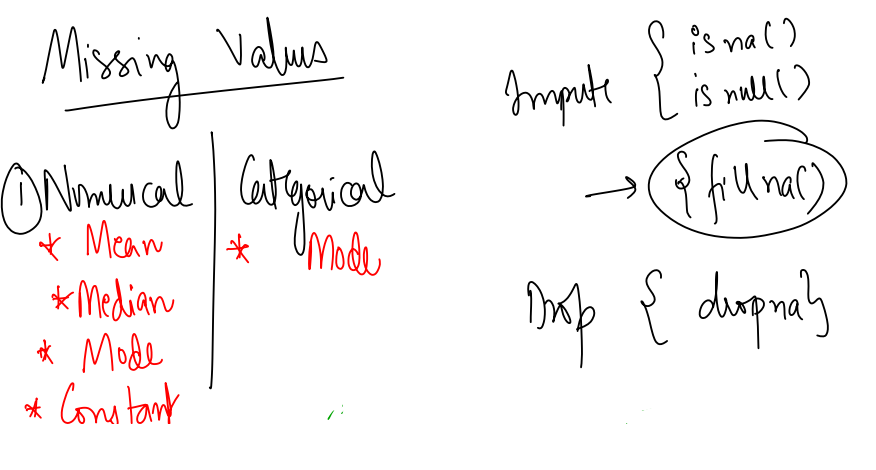

Before understanding what we need let's first work with a single column.

In [ ]:
data["Credit_History"].value_counts()

,count
Credit_History,
1.0,475
0.0,89


In [ ]:
data["Credit_History"].isna().sum()

np.int64(50)

In [ ]:
data.shape

(614, 18)

Out of 614 values, 50 values are missing from the "Credit History" column which is a huge number so we can't just drop the missing values.

So how do I replace these missing values?

<font color='violet'>First, tell me whether **"Credit History"** is a categorical column or a Numerical column?</font>

- **"Credit History"** is represented numerically as 0 and 1, but it's actually categorical.
- It has values like 0 (no credit history), 1 (credit history), and missing values.

<font color='violet'>What should I replace these missing values with?</font>

- One option is to replace them with a new value like "2," but this may not be effective.
- Another option is to replace them with the mode, which is 1.
- However, this could introduce bias since assuming a credit history for missing values might not be accurate.

- If I'm replacing with 1, then I'm making this data biased towards 1
- The best 2 possible ways are 1st to replace with "0" as the values are missing and there will be some reason why these values kept missing by the applicant so it is safer to replace with 0 but this will also create problems.

<font color='violet'>Before imputing missing data, we need to determine if "Credit History" is significant with respect to our target variable.</font>

- This involves conducting tests to check the dependency between columns. If the columns are dependent, we can proceed with imputation. Otherwise, we can simply drop the missing values.

In [ ]:
pd.crosstab(data["Credit_History"],data["Loan_Status"])

Loan_Status,N,Y
Credit_History,,
0.0,82,7
1.0,97,378


In [ ]:
from scipy.stats import chi2_contingency

# H0: Credit history  and Loan status is independent

chi2_contingency(pd.crosstab(data['Credit_History'], data['Loan_Status']))

Chi2ContingencyResult(statistic=np.float64(174.63729658142535), pvalue=np.float64(7.184759548750746e-40), dof=1, expected_freq=array([[ 28.2464539,  60.7535461],
       [150.7535461, 324.2464539]]))

- As we can see p-value is very very low which is $7.18 *10e^{-40} $  

- It means we **reject the null hypothesis** means Credit history and Loan status are **not independent**. They both are dependent on each other.

Let's plot the countplot

<Axes: xlabel='Credit_History', ylabel='count'>

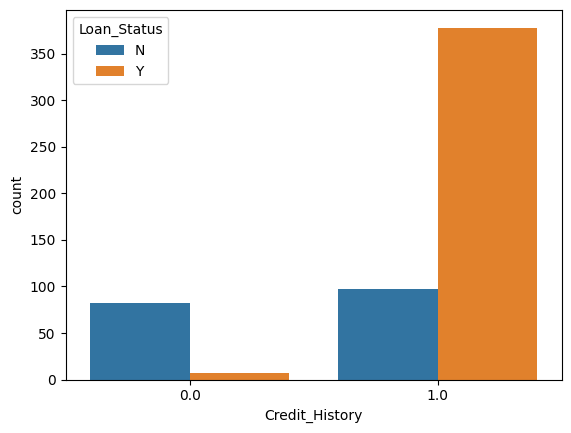

In [ ]:
sns.countplot(x= data["Credit_History"],hue=data["Loan_Status"])

- This chart illustrates that individuals with no credit history (Credit History = 0) have a significantly lower rate of loan approval compared to those with a credit history (Credit History = 1).
- Most applicants with a credit history were approved for their loans, while very few without a credit history had their applications approved.

<font color='violet'> Now coming back to missing values in "Credit History", let's try replacing them with **2** using `fillna()`</font>

In [ ]:
data["Credit_History"]=data["Credit_History"].fillna(2)
data["Credit_History"].value_counts()

,count
Credit_History,
1.0,475
0.0,89
2.0,50


Next, we'll create groups and compare columns by conducting tests and calculating p-values.
We can apply this approach to other columns as well. Let's explore further.

In [ ]:
data["Self_Employed"].value_counts()

,count
Self_Employed,
No,500
Yes,82


In [ ]:
data["Self_Employed"].isna().sum()

np.int64(32)

We have **32** missing values in the "Self Employed" column, which is categorical data. To replace the missing values, we'll use the mode, which is the most frequently occurring value.

Before imputing missing values, let's calculate the p-value.

In [ ]:
pd.crosstab(data['Self_Employed'], data['Loan_Status'])

Loan_Status,N,Y
Self_Employed,,
No,157,343
Yes,26,56


In [ ]:
chi2_contingency(pd.crosstab(data['Self_Employed'], data['Loan_Status']))

Chi2ContingencyResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), dof=1, expected_freq=array([[157.21649485, 342.78350515],
       [ 25.78350515,  56.21649485]]))

However, the p-value is 1.0, indicating that we failed to reject the null hypothesis, suggesting that these two columns are independent of each other.

Since the columns are independent, we can fill the missing values with any category. Let's try filling them with "Other" and reassess.

In [ ]:
data["Self_Employed"]=data["Self_Employed"].fillna("Other")

In [ ]:
data["Self_Employed"].isna().sum()

np.int64(0)

In [ ]:
data["Self_Employed"].value_counts()

,count
Self_Employed,
No,500
Yes,82
Other,32


As you can see all the missing values are being replaced with "Other".

In [ ]:
chi2_contingency(pd.crosstab(data['Self_Employed'], data['Loan_Status']))

Chi2ContingencyResult(statistic=np.float64(0.15849843135909122), pvalue=np.float64(0.9238096679003514), dof=2, expected_freq=array([[156.35179153, 343.64820847],
       [ 10.00651466,  21.99348534],
       [ 25.64169381,  56.35830619]]))

- The p-value remains high, indicating that we still fail to reject the null hypothesis.
- This approach demonstrates one method of filling values using the `fillna()` function. Now, let's explore alternative techniques.

#### <font color='violet'>Simple Imputer [5 mins] </font>

In [ ]:
from sklearn.impute import SimpleImputer

Let me create one simple sample dataframe containing the missing values as **np.nan**



In [ ]:
a = pd.DataFrame([10, 10, 20, 10, 30, 10, np.nan, 50])
a

,0
0,10.0
1,10.0
2,20.0
3,10.0
4,30.0
5,10.0
6,NaN
7,50.0


In [ ]:
a.mean()

,0
0,20.0


Here if you calculate the mean it'll ignore the missing values and will consider only non-missing values

To address this, we can use the `SimpleImputer` class in Python.
- This class offers various imputation strategies, such as "mean," "median," "most_frequent," or "constant," allowing us to choose the most suitable method based on our needs.

###### <font color='lightgreen'>Strategy = Mean</font>

In [ ]:
# df.apply(function(x))

In [ ]:
SimpleImputer(strategy="mean").fit_transform(a) # Apply this strategy on the databframe

array([[10.],
       [10.],
       [20.],
       [10.],
       [30.],
       [10.],
       [20.],
       [50.]])

- Here, I'm using `fit_transform()`, which combines the functions "fit" and "transform."
   - This operation is akin to the "apply" function.
   -  You will learn in-depth about this function in the ML module.

In this scenario, missing values are replaced with the "mean" of the data, and you can observe that `np.nan` is substituted with "20".

###### <font color='lightgreen'>Strategy = most_frequent(mode)</font>

In [ ]:
a.mode()

,0
0,10.0


Here we are imputing the missing value with the most frequent value in the dataframe which is 10.

In [ ]:
SimpleImputer(strategy="most_frequent").fit_transform(a)

array([[10.],
       [10.],
       [20.],
       [10.],
       [30.],
       [10.],
       [10.],
       [50.]])

###### <font color='lightgreen'>Strategy = Constant</font>

Imputing missing values with some constant value. We have to pass the value in the fill_value parameter.

In [ ]:
SimpleImputer(strategy="constant",fill_value=1000).fit_transform(a) # Akin to apply function

array([[  10.],
       [  10.],
       [  20.],
       [  10.],
       [  30.],
       [  10.],
       [1000.],
       [  50.]])

Instead of individually handling missing values in each column, we can categorize columns based on patterns. For example, we might decide to use mean imputation for one set of columns and median imputation for another.

- To implement this, we create a list of columns and instantiate the "SimpleImputer" class with the strategy set to "median."
- Then, we can iterate through the list and replace all missing values at once.
- This approach is not only more streamlined but also allows for the reusability of the imputer object.

In [ ]:
pd.DataFrame(median_imputer.fit_transform(pd.DataFrame(data[col])))

,0
0,30.0
1,30.0
2,30.0
3,30.0
4,30.0
...,...
609,30.0
610,15.0
611,30.0
612,30.0


In [ ]:
# Missing numeric columns

# set of columns
num_missing = ['EMI', 'Loan_Amount_per_year',  'LoanAmount',  'Loan_Amount_Term']

# instance of simple imputer class with a median strategy
median_imputer = SimpleImputer(strategy = 'median')

for col in num_missing:
    data[col] = pd.DataFrame(median_imputer.fit_transform(pd.DataFrame(data[col])))

In [ ]:
data[num_missing].isnull().sum()

,0
EMI,0
Loan_Amount_per_year,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
cat_missing = ['Gender', 'Married','Dependents']

freq_imputer = SimpleImputer(strategy = 'most_frequent') # mode
for col in cat_missing:
    data[col] = pd.DataFrame(freq_imputer.fit_transform(pd.DataFrame(data[col])))

In [ ]:
data[cat_missing].isnull().sum()

,0
Gender,0
Married,0
Dependents,0


Now, let's check if there are any missing values in the dataset.

In [ ]:
data.isna().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


<font color='violet'>**TADAAAA!!! No More Missing Values.**</font>

---

# Quiz-1 [5 mins]

```
During EDA, you notice that the feature 'Age' has some missing values.

What is an appropriate approach to handle missing data in this feature?

Which code snippet accomplishes this?

data = pd.DataFrame({'Age': [12, 15, 24, 25, 30, 44, 45, 32, None, 56, 51, 28, None, 98, 43, 52, 86, 91]})
```
A.
```
imputer = SimpleImputer(strategy='mean')
data['Age'] = imputer.fit_transform(data[['Age']])
```

B.
```
imputer = SimpleImputer(strategy='median')
data['Age'] = imputer.fit_transform(data[['Age']])
```

C.
```
imputer = SimpleImputer(strategy='median')
data['Age'] = imputer.apply(data[['Age']])
```

D.
```
imputer = SimpleImputer(strategy=’most_frequent’)
data['Age'] = imputer.apply(data[['Age']])
```

**Options:**
- [ ] A
- [ ] B
- [ ] C
- [ ] D

<details>
**Answer:**

- [ ] A
- [x] B
- [ ] C
- [ ] D


```
imputer = SimpleImputer(strategy='median')
data['Age'] = imputer.fit_transform(data[['Age']])
```
</details>

**Explanation:**

<Axes: >

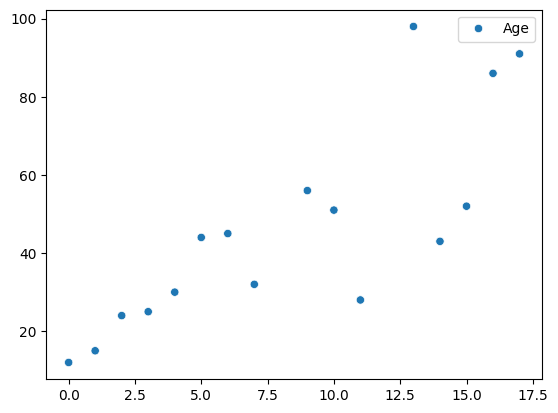

In [ ]:
from sklearn.impute import SimpleImputer
import pandas as pd
import seaborn as sns

# Assuming 'test_data' is a DataFrame with missing values in the 'Age' column
test_data = pd.DataFrame({'Age': [12, 15, 24, 25, 30, 44, 45, 32, None, 56, 51, 28, None, 98, 43, 52, 86, 91]})

sns.scatterplot(test_data)

**From the graph we can see there are three outliers present in the data. Hence, we use the median to impute the null values.**

In [ ]:
# Create a SimpleImputer with the median strategy
imputer = SimpleImputer(strategy='median')

# Fit and transform the data
test_data['Age'] = imputer.fit_transform(test_data[['Age']])

# Print the imputed data
print(test_data)

     Age
0   12.0
1   15.0
2   24.0
3   25.0
4   30.0
5   44.0
6   45.0
7   32.0
8   43.5
9   56.0
10  51.0
11  28.0
12  43.5
13  98.0
14  43.0
15  52.0
16  86.0
17  91.0


- **Delete rows with missing 'Age' values:** This could result in valuable data loss, especially if missing values are not randomly distributed. It's generally recommended to avoid removing rows with missing data unless it's a small portion of the dataset.
- **Impute missing values with the mean age:** Mean imputation is common but sensitive to outliers.
- **Impute missing values with a fixed value like -1:** This introduces a fixed bias into the data and may not accurately represent the 'Age' feature's distribution.
- **Impute missing values with the median age:** Using the median helps maintain the data's overall distribution while handling missing values and is less sensitive to outliers compared to mean imputation.

---
## <font color='sky blue'>**Outlier Treatment** [5 mins] </font>

We saw how to address the missing values using the technique like Simple Imputer.

Now, what do we do for extreme values?

<font color='violet'>Outliers are data points that significantly deviate from the rest of the data and can distort results. Identifying and addressing outliers is essential to ensure the reliability and effectiveness of our analyses.</font>

Removing outliers helps mitigate their influence on the analysis, resulting in more robust and accurate models that better capture patterns in the data.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gender                614 non-null    object 
 1   Married               614 non-null    object 
 2   Dependents            614 non-null    object 
 3   Education             614 non-null    object 
 4   Self_Employed         614 non-null    object 
 5   ApplicantIncome       614 non-null    int64  
 6   CoapplicantIncome     614 non-null    float64
 7   LoanAmount            614 non-null    float64
 8   Loan_Amount_Term      614 non-null    float64
 9   Credit_History        614 non-null    float64
 10  Property_Area         614 non-null    object 
 11  Loan_Status           614 non-null    object 
 12  Income_bin            614 non-null    object 
 13  TotalIncome           614 non-null    float64
 14  TotalIncome_bin       614 non-null    object 
 15  Loan_Amount_per_year  6

In [ ]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_bin,TotalIncome,TotalIncome_bin,Loan_Amount_per_year,EMI,Able_to_pay_EMI
0,Male,No,0,Graduate,No,5849,0.0,128.0,30.0,1.0,Urban,Y,Medium,5849.0,High,4.383333,365.277778,0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,30.0,1.0,Rural,N,Medium,6091.0,High,4.266667,355.555556,1
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,30.0,1.0,Urban,Y,Average,3000.0,Low,2.200000,183.333333,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,30.0,1.0,Urban,Y,Average,4941.0,Average,4.000000,333.333333,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,30.0,1.0,Urban,Y,Medium,6000.0,High,4.700000,391.666667,1


In [ ]:
# filter the numeric variables from the data
df_num = data.select_dtypes(include = np.number)

df_num.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'TotalIncome',
       'Loan_Amount_per_year', 'EMI', 'Able_to_pay_EMI'],
      dtype='object')

In [ ]:
df_num.drop(['Credit_History','Able_to_pay_EMI'],axis=1,inplace=True)
df_num.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,TotalIncome,Loan_Amount_per_year,EMI
0,5849,0.0,128.0,30.0,5849.0,4.383333,365.277778
1,4583,1508.0,128.0,30.0,6091.0,4.266667,355.555556
2,3000,0.0,66.0,30.0,3000.0,2.200000,183.333333
3,2583,2358.0,120.0,30.0,4941.0,4.000000,333.333333
4,6000,0.0,141.0,30.0,6000.0,4.700000,391.666667


### <font color='violet'>Outliers visualisation using Boxplots</font>

Seaborn's `boxplot()` function creates a visual representation of the data distribution.

The box signifies the data's quartiles, while the whiskers extend to show the remaining data range.

Outliers are identified using the **interquartile range (IQR)** method.

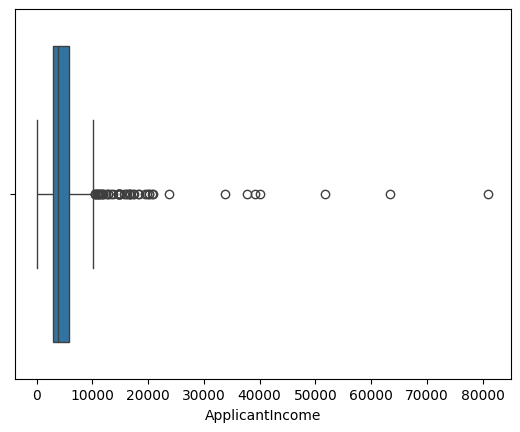

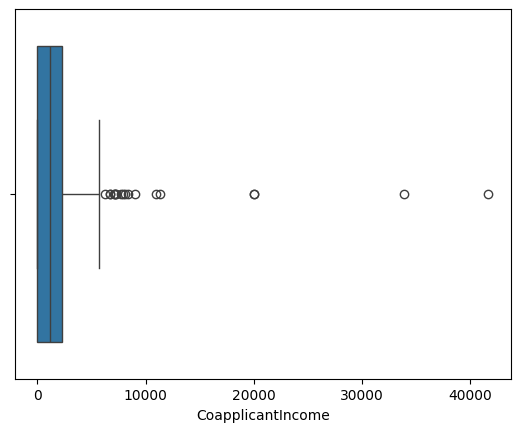

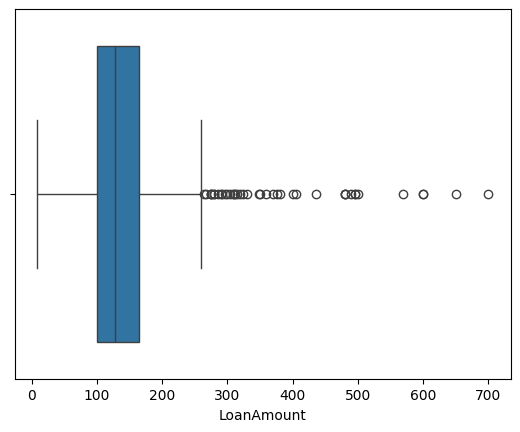

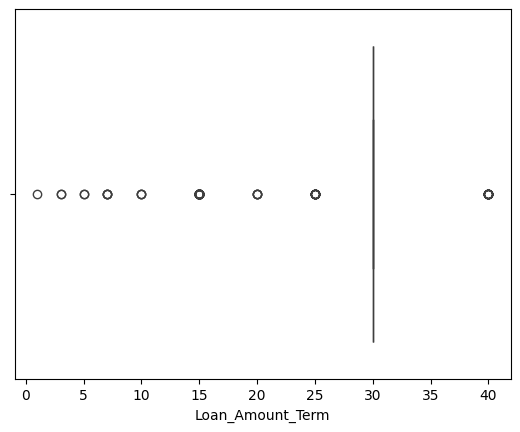

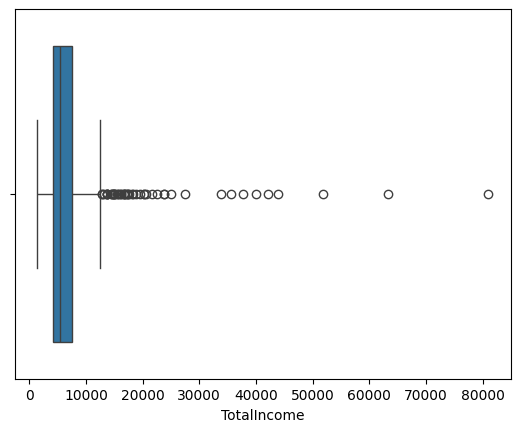

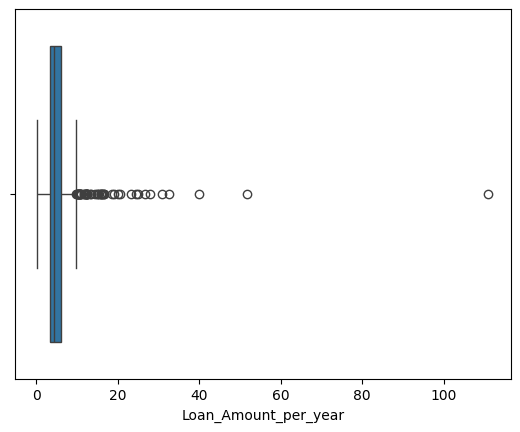

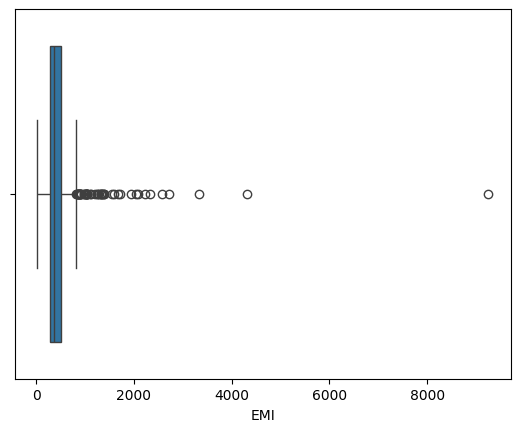

In [ ]:
for col in enumerate(df_num):
    sns.boxplot(x=col[1],data=df_num)
    plt.show()

From the above plots, we can see that there are outliers present in the data.

There are **two** methods with which we can treat the outliers:

1. <font color='violet'>IQR (Interquartile Range) Method:</font>

- Calculate the IQR (the difference between the 75th and 25th percentiles) and remove values outside a specified range (e.g., 1.5 times IQR).

2. <font color='violet'>Z-Score or Standard Score:</font>

- Identify and remove data points with z-scores beyond a certain threshold (e.g., ±3).

### <font color='violet'>IQR (Interquartile Range) Method [10 mins] </font>

In [ ]:
# Q3-Q1

In [ ]:
# obtain the first quartile
Q1 = df_num.quantile(0.25)

# obtain the third quartile
Q3 = df_num.quantile(0.75)

# obtain the IQR
IQR = Q3 - Q1

# print the IQR
print(IQR)

ApplicantIncome         2917.500000
CoapplicantIncome       2297.250000
LoanAmount                64.500000
Loan_Amount_Term           0.000000
TotalIncome             3355.750000
Loan_Amount_per_year       2.500000
EMI                      208.333333
dtype: float64


In [ ]:
data.shape

(614, 18)

In [ ]:
df_num.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,TotalIncome,Loan_Amount_per_year,EMI
0,5849,0.0,128.0,30.0,5849.0,4.383333,365.277778
1,4583,1508.0,128.0,30.0,6091.0,4.266667,355.555556
2,3000,0.0,66.0,30.0,3000.0,2.200000,183.333333
3,2583,2358.0,120.0,30.0,4941.0,4.000000,333.333333
4,6000,0.0,141.0,30.0,6000.0,4.700000,391.666667


In [ ]:
data.shape

(614, 18)

In [ ]:
data[~(df_num < Q1 - 1.5 * IQR).any(axis=1)]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_bin,TotalIncome,TotalIncome_bin,Loan_Amount_per_year,EMI,Able_to_pay_EMI
0,Male,No,0,Graduate,No,5849,0.0,128.0,30.0,1.0,Urban,Y,Medium,5849.0,High,4.383333,365.277778,0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,30.0,1.0,Rural,N,Medium,6091.0,High,4.266667,355.555556,1
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,30.0,1.0,Urban,Y,Average,3000.0,Low,2.200000,183.333333,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,30.0,1.0,Urban,Y,Average,4941.0,Average,4.000000,333.333333,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,30.0,1.0,Urban,Y,Medium,6000.0,High,4.700000,391.666667,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,Male,Yes,0,Graduate,No,3232,1950.0,108.0,30.0,1.0,Rural,Y,Average,5182.0,High,3.600000,300.000000,1
609,Female,No,0,Graduate,No,2900,0.0,71.0,30.0,1.0,Rural,Y,Average,2900.0,Low,2.366667,197.222222,1
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,30.0,1.0,Urban,Y,H2,8312.0,Very High,8.433333,702.777778,1
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,30.0,1.0,Urban,Y,H1,7583.0,High,6.233333,519.444444,1


In [ ]:
# 1. Lower Limit

ll = Q1 - 1.5 * IQR
ul = Q3 + 1.5 * IQR

data[(~(df_num < ll).any(axis=1)) | (~(df_num > ul).any(axis=1))]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_bin,TotalIncome,TotalIncome_bin,Loan_Amount_per_year,EMI,Able_to_pay_EMI
0,Male,No,0,Graduate,No,5849,0.0,128.0,30.0,1.0,Urban,Y,Medium,5849.0,High,4.383333,365.277778,0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,30.0,1.0,Rural,N,Medium,6091.0,High,4.266667,355.555556,1
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,30.0,1.0,Urban,Y,Average,3000.0,Low,2.200000,183.333333,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,30.0,1.0,Urban,Y,Average,4941.0,Average,4.000000,333.333333,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,30.0,1.0,Urban,Y,Medium,6000.0,High,4.700000,391.666667,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,30.0,1.0,Rural,Y,Average,2900.0,Low,2.366667,197.222222,1
610,Male,Yes,3,Graduate,No,4106,0.0,40.0,15.0,1.0,Rural,Y,Medium,4106.0,Average,2.666667,222.222222,1
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,30.0,1.0,Urban,Y,H2,8312.0,Very High,8.433333,702.777778,1
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,30.0,1.0,Urban,Y,H1,7583.0,High,6.233333,519.444444,1


In [ ]:
~(df_num < Q1 - 1.5 * IQR).any(axis=1)

,0
0,True
1,True
2,True
3,True
4,True
...,...
609,True
610,False
611,True
612,True


The shape of our dataset is (614, 18), which means it contains 614 rows and 18 columns.


In [ ]:
df_iqr = data[~((df_num < (Q1-1.5 * IQR))|(df_num > (Q3 + 1.5 * IQR))).any(axis=1)]

---  

***Instructor's note:*** Explanation of code:  

- `(df_num < (Q1 - 1.5 * IQR))` checks for values below the lower bound (Q1 - 1.5 * IQR).  

- `(df_num > (Q3 + 1.5 * IQR))` checks for values above the upper bound (Q3 + 1.5 * IQR).  

- `~((df_num < (Q1 - 1.5 * IQR)) | (df_num > (Q3 + 1.5 * IQR)))`:
  
  - The ~ operator negates this condition, selecting rows where none of the values are below the lower bound or above the upper bound.   
  
  - In other words, it selects rows that are within the lower and upper range defined by the interquartile range (IQR) method.

- `any(axis=1)`:   

  - The any(axis=1) checks if any True value exists along the rows. If a row has at least one True value (indicating it's an outlier), the negation will make it False, and vice versa.

---

In [ ]:
df_iqr.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_bin,TotalIncome,TotalIncome_bin,Loan_Amount_per_year,EMI,Able_to_pay_EMI
0,Male,No,0,Graduate,No,5849,0.0,128.0,30.0,1.0,Urban,Y,Medium,5849.0,High,4.383333,365.277778,0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,30.0,1.0,Rural,N,Medium,6091.0,High,4.266667,355.555556,1
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,30.0,1.0,Urban,Y,Average,3000.0,Low,2.200000,183.333333,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,30.0,1.0,Urban,Y,Average,4941.0,Average,4.000000,333.333333,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,30.0,1.0,Urban,Y,Medium,6000.0,High,4.700000,391.666667,1


In [ ]:
# check the shape of the data
df_iqr.shape

(458, 18)

After removing the outliers the shape of our dataset is (458, 18), which means it contains 458 rows and 18 columns.

### <font color='violet'>Z-Score or Standard Score: [10 mins]</font>

The Z-score of a value is the difference between that value and the mean, divided by the standard deviation.

If the z-score is greater than 3 or less than -3, indicates an outlier value.

In [ ]:
z_score_la = (df_num["LoanAmount"] - df_num["LoanAmount"].mean()) /df_num["LoanAmount"] .std()

In [ ]:
import scipy
from scipy import stats

# z-scores are defined for each observation in a variable
# compute the z-scores using the method zscore from the scipy library
z_scores_LoanAmount = scipy.stats.zscore(df_num["LoanAmount"])

# display the z-scores
z_scores_LoanAmount

array([-2.11241249e-01, -2.11241249e-01, -9.48996468e-01, -3.06435471e-01,
       -5.65506391e-02,  1.44275835e+00, -6.03917414e-01,  1.45737082e-01,
        2.64729859e-01,  2.41849913e+00, -9.01399357e-01, -4.37327526e-01,
        6.45506746e-01, -3.77831138e-01, -1.53206108e+00, -2.46939083e-01,
       -5.44421026e-01, -8.30003691e-01, -1.51744861e-01, -3.65931860e-01,
       -4.96823915e-01,  2.01392368e+00, -3.54032582e-01, -4.01629693e-01,
        6.24421381e-02,  5.38413247e-01, -2.82636916e-01, -4.25428248e-01,
       -1.31787408e+00, -3.06435471e-01,  6.57406024e-01, -8.53802246e-01,
       -4.73025359e-01, -3.77831138e-01,  2.07342007e+00, -2.11241249e-01,
       -5.44421026e-01, -2.08528059e-02,  4.55118303e-01, -4.25428248e-01,
       -7.82406580e-01, -1.17508274e+00, -8.41902969e-01, -1.39845583e-01,
       -5.92018136e-01, -6.87212358e-01, -1.21078058e+00, -2.08528059e-02,
       -3.06435471e-01, -2.08528059e-02, -5.44421026e-01, -3.06435471e-01,
       -4.01629693e-01, -

In [ ]:
# print the rows where the z-score is less than -3
row_index_less = np.where(z_scores_LoanAmount < -3) # True, False

# print the values
print(row_index_less)

(array([], dtype=int64),)


In [ ]:
row_index_less

(array([], dtype=int64),)

In [ ]:
# print the rows where the z-score is more than 3
row_index_more = np.where(z_scores_LoanAmount > 3)

# print the values more than the
print(row_index_more)

(array([130, 155, 171, 177, 278, 308, 333, 369, 432, 487, 506, 523, 525,
       561, 604]),)


The rows corresponding to the above displayed index are the outliers for the data.

In [ ]:
# count of outliers in the variable representing LoanAmount
len(row_index_less[0]) + len(row_index_more[0])

15

There are 15 outliers in the data.

In [ ]:
# Filter out the outlier values
# ~: Select all rows which do not satisfy the condition
df_LoanAmount_zscore = data["LoanAmount"][~(( z_scores_LoanAmount < -3) |(z_scores_LoanAmount > 3))]

---  

***Instructor's note:*** Explanation of code.


- `(z_scores_LoanAmount < -3) | (z_scores_LoanAmount > 3)` identifies Z-scores that are below -3 or above 3, indicating potential outliers.  
  - We are using `~` to negate this condition as we only want those rows with z scores within this range.  

- Then we are creating a new Series `(df_LoanAmount_zscore)` containing values from the `LoanAmount` column having z scores within this range

---

In [ ]:
# check the shape
df_LoanAmount_zscore.shape

(599,)

Now, let's apply this method to remove outliers from complete dataset.

In [ ]:
data.shape

(614, 18)

The shape of our dataset is (614, 18), which means it contains 614 rows and 18 columns.

In [ ]:
data.select_dtypes(include=[np.number])

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,Loan_Amount_per_year,EMI,Able_to_pay_EMI
0,5849,0.0,128.0,30.0,1.0,5849.0,4.383333,365.277778,0
1,4583,1508.0,128.0,30.0,1.0,6091.0,4.266667,355.555556,1
2,3000,0.0,66.0,30.0,1.0,3000.0,2.200000,183.333333,1
3,2583,2358.0,120.0,30.0,1.0,4941.0,4.000000,333.333333,1
4,6000,0.0,141.0,30.0,1.0,6000.0,4.700000,391.666667,1
...,...,...,...,...,...,...,...,...,...
609,2900,0.0,71.0,30.0,1.0,2900.0,2.366667,197.222222,1
610,4106,0.0,40.0,15.0,1.0,4106.0,2.666667,222.222222,1
611,8072,240.0,253.0,30.0,1.0,8312.0,8.433333,702.777778,1
612,7583,0.0,187.0,30.0,1.0,7583.0,6.233333,519.444444,1


In [ ]:
z_score_threshold = 3  # You can adjust this threshold as needed

# Calculate z-scores for all numerical columns
z_scores = np.abs(stats.zscore(data.select_dtypes(include=[np.number])))

# Remove rows with any z-score exceeding the threshold
data_no_outliers = data[(z_scores < z_score_threshold).all(axis=1)]

In [ ]:
data_no_outliers.shape

(541, 18)

The shape of our dataset is (541, 18), which means it contains 541 rows and 18 columns.

<font color='violet'>How to decide which method to use for outlier treatment?</font>

Consider the nature of your data and your analysis goals.

- The **Z-Score method** is ideal when your data approximates a **normal distribution** and is symmetric.
  - It quantifies data points in terms of standard deviations from the mean, making it effective for large datasets.

- On the other hand, the **IQR (Interquartile Range) method** is best when your data **doesn't follow a normal distribution or is skewed**.
  - It defines a central range based on percentiles and is less sensitive to outliers, making it a robust choice, particularly for smaller datasets.

Since we've studied about correlation,

<font color="violet">Which correlation method do you think would be more robust towards outliers in data?</font>

- When dealing with outliers in data, Spearman Correlation is more robust compared to Pearson Correlation.
  - While Pearson Correlation is sensitive to outliers as it operates directly on the original data, Spearman Correlation works on the ranks of data, making it less affected by outliers.
  - It focuses on the monotonic relationship between variables rather than the specific values, allowing it to handle outliers more effectively.

<font color="violet">Applicability of CLT on data with outliers</font>

The Central Limit Theorem (CLT) applies to data, even if it's not normally distributed, as long as certain conditions are met:

- The sample size should be large, typically $n ≥ 30$.
- Samples should be collected independently and randomly.
- The population standard deviation should have a finite value.
  - If finite, CLT applies without restrictions on the shape of the population distribution, especially for larger sample sizes.
  - If infinite or not well-defined, CLT still holds but may require a larger sample size for the sampling distribution to approach normality.

However, CLT might not be ideal for datasets with outliers.

- Outliers can skew the mean, affecting the accuracy of estimating the population mean.
- In such cases, using Bootstrapping is recommended.
  - Bootstrapping doesn't rely on assumptions about the underlying distribution and is more robust in the presence of outliers.

---

# Quiz-2 [5 mins]

```
You have a dataset with the following values: [15, 18, 22, 23, 25, 28, 40, 75, 200].

After applying the IQR method for outlier treatment, which values would be considered outliers?
```

**Options:**

- [ ] 18, 25, 200
- [ ] 75, and 200
- [ ] 40 and 75
- [ ] None of the values are outliers

<details>
**Explanation:**

- [ ] 18, 25, 200
- [x] 75, and 200
- [ ] 40 and 75
- [ ] None of the values are outliers

To determine outliers using the IQR (Interquartile Range) method, we need to calculate the IQR for the dataset.
The IQR is the difference between the third quartile (Q3) and the first quartile (Q1).
</details>


In [ ]:
import numpy as np

# Given dataset
data = np.array([15, 18, 22, 23, 25, 28, 40, 75, 200])

# Calculate Q1, Q3, and IQR
Q1 = np.percentile(data, 25) # quartile
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

# Determine the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# # Identify outliers
# outliers = [value for value in data if value < lower_bound or value > upper_bound]
outliers = []

for value in data:
  if value < lower_bound or value > upper_bound:
    outliers.append(value)



# Print the results
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Identified Outliers:", outliers)

Lower Bound: -5.0
Upper Bound: 67.0
Identified Outliers: [np.int64(75), np.int64(200)]


- Any values that fall below the lower bound or above the upper bound are considered outliers.
- In this case, the values 75, and 200 are outside the upper bound, so they are considered outliers.
---

## <font color='violet'>Categorical to Numerical [20 mins]</font>

- Now, let's dive into another crucial aspect of today's class.

Here's an intriguing question for all of you:

We have a categorical column named "Gender" with values "Male" and "Female" represented as strings.

Computers can't process strings directly; they only understand numerical values like 0s and 1s.

This presents a challenge for us because our dataset contains categorical columns.

In [ ]:
df_iqr.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_bin,TotalIncome,TotalIncome_bin,Loan_Amount_per_year,EMI,Able_to_pay_EMI
0,Male,No,0,Graduate,No,5849,0.0,128.0,30.0,1.0,Urban,Y,Medium,5849.0,High,4.383333,365.277778,0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,30.0,1.0,Rural,N,Medium,6091.0,High,4.266667,355.555556,1
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,30.0,1.0,Urban,Y,Average,3000.0,Low,2.200000,183.333333,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,30.0,1.0,Urban,Y,Average,4941.0,Average,4.000000,333.333333,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,30.0,1.0,Urban,Y,Medium,6000.0,High,4.700000,391.666667,1


Let's separate categorical data & numerical data into two dataframes

In [ ]:
df_iqr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 458 entries, 0 to 613
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gender                458 non-null    object 
 1   Married               458 non-null    object 
 2   Dependents            458 non-null    object 
 3   Education             458 non-null    object 
 4   Self_Employed         458 non-null    object 
 5   ApplicantIncome       458 non-null    int64  
 6   CoapplicantIncome     458 non-null    float64
 7   LoanAmount            458 non-null    float64
 8   Loan_Amount_Term      458 non-null    float64
 9   Credit_History        458 non-null    float64
 10  Property_Area         458 non-null    object 
 11  Loan_Status           458 non-null    object 
 12  Income_bin            458 non-null    object 
 13  TotalIncome           458 non-null    float64
 14  TotalIncome_bin       458 non-null    object 
 15  Loan_Amount_per_year  458 no

In [ ]:
num=df_iqr.select_dtypes(include=np.number)
num.drop(['Able_to_pay_EMI','Credit_History'],axis=1,inplace=True)
num.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,TotalIncome,Loan_Amount_per_year,EMI
0,5849,0.0,128.0,30.0,5849.0,4.383333,365.277778
1,4583,1508.0,128.0,30.0,6091.0,4.266667,355.555556
2,3000,0.0,66.0,30.0,3000.0,2.200000,183.333333
3,2583,2358.0,120.0,30.0,4941.0,4.000000,333.333333
4,6000,0.0,141.0,30.0,6000.0,4.700000,391.666667


In [ ]:
cat = df_iqr.select_dtypes(include=['object'])
cat.drop('Loan_Status',axis=1,inplace=True)
cat['Able_to_pay_EMI'] = df_iqr['Able_to_pay_EMI']
cat['Credit_History'] = df_iqr['Credit_History']
cat.head()

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Income_bin,TotalIncome_bin,Able_to_pay_EMI,Credit_History
0,Male,No,0,Graduate,No,Urban,Medium,High,0,1.0
1,Male,Yes,1,Graduate,No,Rural,Medium,High,1,1.0
2,Male,Yes,0,Graduate,Yes,Urban,Average,Low,1,1.0
3,Male,Yes,0,Not Graduate,No,Urban,Average,Average,1,1.0
4,Male,No,0,Graduate,No,Urban,Medium,High,1,1.0


In [ ]:
## Target Column
Target = df_iqr['Loan_Status']
Target.head()

,Loan_Status
0,Y
1,N
2,Y
3,Y
4,Y


### <font color='violet'>Categorical Data</font>

We need to understand two key concepts:

- First, how can we effectively represent the information in our data to capture all trends and important details?
- Secondly, we must present this information in a format that the model can understand and interpret.

Since models only comprehend numbers, we need to convert our categorical data into numerical data.

<font color='violet'>How do we do that? </font>

There are three methods:
1. One Hot Encoding
2. Label Encoding
3. Target Encoding



#### <font color='lightgreen'>One Hot Encoding</font>

Let's understand it with an example


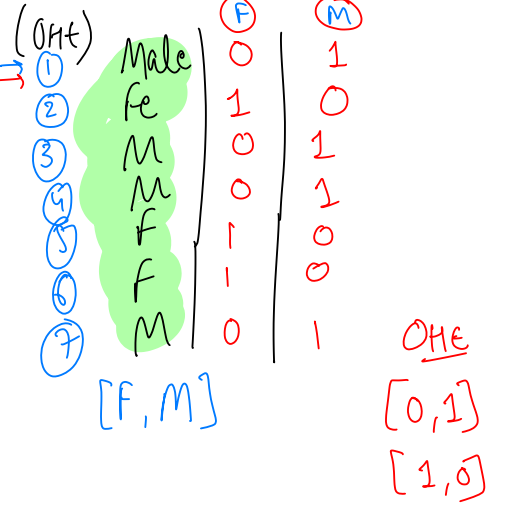

I have a dataset here, what do I do here?

- Create a dictionary with two values: ["F", "M"]. Use this dictionary to create two columns in the dataset: "F" and "M".
- If a row has the value "M", assign 0 to the "F" column and 1 to the "M" column.
- Create a vector where the first position represents whether the person is female (1 for yes, 0 for no) and the second position represents whether the person is male (1 for yes, 0 for no).
- Fill the "F" and "M" columns with 0s and 1s accordingly.

You will learn in more detail in the ML module.

#### <font color='lightgreen'>Label Encoding</font>  

- In this dataset, we'll assign "Male" as 0 and "Female" as 1. Label encoding is suitable when there are only two categories in the dataset, like in this case, as it simplifies the representation without any issues.





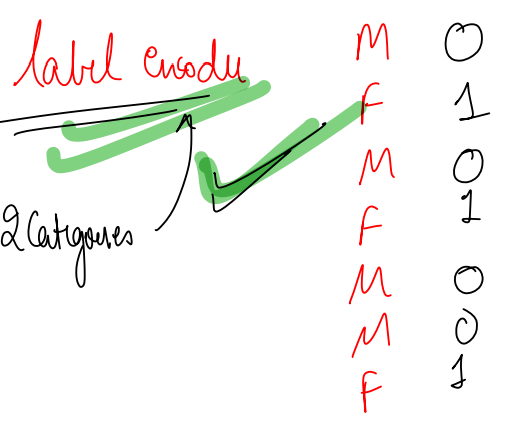

Now I'm giving you one situation and think about it what is the problem in the situation?  

- I'm representing different categories here basically more than 2 categories.  

- Suppose I have 5 different categories A, B, C, D, E and if we apply label encoding on it then  

  Cat A -> 0  
  Dog B -> 1  
  Elephant c -> 2  
  Turtle D -> 3  
  Rat E -> 4  

<font color='violet'>What is the problem here?</font>  

- In the given situation with five categories A, B, C, D, and E, applying label encoding introduces an unintended order to the categories, implying an inherent hierarchy where none exists.
  - $Cat < Dog < Elephant < Turtle < Rat$
- This can lead to bias in the model, as it may assign greater importance to categories with higher numerical labels.

To avoid this issue, especially when dealing with more than two categories, it's advisable to use target encoding instead of label encoding.

Target encoding assigns numerical values based on the target variable, ensuring that no implicit order is introduced.

Another option is one-hot encoding (OHE), but target encoding is preferred over OHE as it avoids creating sparse data with numerous zeros and only a single one.
  - This means there are so many 0s and only a single 1.


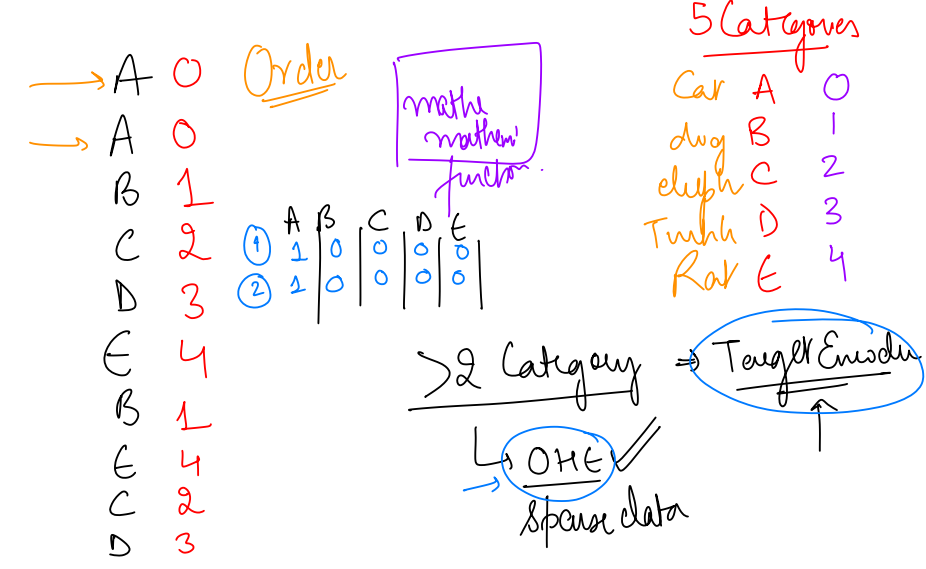

Now, let's start by identifying all the categorical columns in the dataset.

In [ ]:
cat.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Income_bin', 'TotalIncome_bin', 'Able_to_pay_EMI',
       'Credit_History'],
      dtype='object')

Let's start working on each column one by one.
- First with **Loan Status**

In [ ]:
Target.value_counts()

,count
Loan_Status,
Y,325
N,133


As it has only 2 categories we can use Lable Encoder here to convert loan status into numerical.


In [ ]:
from sklearn.preprocessing import LabelEncoder

Here also it is the class so we have to create the instance of the class and then using fit_transform we have to apply it to our column.

In [ ]:
col='Loan_Status'
label_encoder=LabelEncoder()
df_iqr[col]=label_encoder.fit_transform(df_iqr[col]) # Apply
df_iqr[col].value_counts()

,count
Loan_Status,
1,325
0,133


- You can clearly see here before this our data was categorical $Y$ and $N$, not it got converted into numerical data.
- $1$ represents $Y$ and $0$ represents $N$
- We can do the same process for the other columns as well as having 2 categories like:  
   - Gender
   - Married
   - Education

By creating an instance of the LableEncoder class we can reuse that object directly and we don't need to every time run it.

In [ ]:
col="Gender"
df_iqr[col]=label_encoder.fit_transform(df_iqr[col])
df_iqr[col].value_counts()

col="Married"
df_iqr[col]=label_encoder.fit_transform(df_iqr[col])
df_iqr[col].value_counts()

col="Education"
df_iqr[col]=label_encoder.fit_transform(df_iqr[col])
df_iqr[col].value_counts()

,count
Education,
0,353
1,105


But what if we have more than 2 categories?

In [ ]:
col="Property_Area"
df_iqr[col].value_counts()

,count
Property_Area,
Semiurban,178
Rural,143
Urban,137


Now, here you can see we have **more than 2 categories** and we can't represent them with labels 0, 1 and 2 it'll create an order within the categories  

Here we are going to use **Target Encoding**

#### <font color='lightgreen'>Target Encoding</font>

In [ ]:
pip install --upgrade category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.2 MB/s eta 0:00:00


In [ ]:
from category_encoders import TargetEncoder

Before proceeding further, let's understand the purpose of Target Encoding.
  - Target Encoding is performed with respect to the target column, which in our case is "Loan Status."
  - To illustrate this, I'll create a crosstab between the target column and the "Property Area" column.

In [ ]:
pd.crosstab(df_iqr["Property_Area"], df_iqr["Loan_Status"])

Loan_Status,0,1
Property_Area,,
Rural,52,91
Semiurban,36,142
Urban,45,92


- What does this number represent that **52** persons belong to **Rural Area** and their loan status is not approved (0)  

- My target here is I want to understand whether the loan is accepted so my target column is loan status and the target value is 1.

- If I want to find the percentage here, how will I find it? can I use the parameter "normalize" here  



In [ ]:
pd.crosstab(df_iqr["Property_Area"], df_iqr["Loan_Status"],normalize="index")

Loan_Status,0,1
Property_Area,,
Rural,0.363636,0.636364
Semiurban,0.202247,0.797753
Urban,0.328467,0.671533


<font color='violet'>Here can anyone tell what 0.63 represents?</font>

- Is it representing  $P(LS = 1 \mid PA = "Rural")$ or $P(PA = "Rural" \mid LS = 1)$
- It represents the probability that the loan status will be 1 given that the property area is "rural."

Now, can I use our Target Values (1) as targets?

- When converting categorical data into numerical data using Target Encoders, it essentially represents these categories in terms of their **probabilities**.

In [ ]:
# pd.crosstab(data["Property_Area"], data["Loan_Status"],margins=True)

In [ ]:
col="Property_Area"
te=TargetEncoder() # create an object

# here I need to pass 2 things as parameters. 1st the column that I'm working on
# 2nd the Target column

df_iqr[col]=te.fit_transform(df_iqr[col],df_iqr["Loan_Status"])
df_iqr[col].value_counts()

,count
Property_Area,
0.797753,178
0.636364,143
0.671533,137


Do you notice how the categorical values were replaced by numerical values, which are essentially the same as their probabilities?

The values are consistent with the crosstab:
- 0.79 for "Semiurban"
- 0.67 for "Urban"
- 0.63 for "Rural"

However, one issue is that there's an implicit order, but the difference between the values is not significant.

Now, let's apply the same process to convert the remaining columns:
- Self_Employed
- Dependents
- Income_bin
- TotalIncome_bin

In [ ]:
# include remaining features in a single cell

col="Self_Employed"
te=TargetEncoder()
df_iqr[col]=te.fit_transform(df_iqr[col],df_iqr["Loan_Status"])
df_iqr[col].value_counts()

col="Dependents"
te=TargetEncoder()
df_iqr[col]=te.fit_transform(df_iqr[col],df_iqr["Loan_Status"])
df_iqr[col].value_counts()

col="Income_bin"
te=TargetEncoder()
df_iqr[col]=te.fit_transform(df_iqr[col],df_iqr["Loan_Status"])
df_iqr[col].value_counts()

col="TotalIncome_bin"
te=TargetEncoder()
df_iqr[col]=te.fit_transform(df_iqr[col],df_iqr["Loan_Status"])
df_iqr[col].value_counts()

,count
TotalIncome_bin,
0.700000,190
0.735135,185
0.725803,44
0.627644,39


Since total income bin is the last code so we are getting the output of that code only.

Let's check if any column still has an "object" data type.

In [ ]:
df_iqr.dtypes

,0
Gender,int64
Married,int64
Dependents,float64
Education,int64
Self_Employed,float64
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,float64


In [ ]:
s = (df_iqr.dtypes == 'object')
object_cols = list(s[s].index)
object_cols

[]

In [ ]:
df_iqr.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_bin,TotalIncome,TotalIncome_bin,Loan_Amount_per_year,EMI,Able_to_pay_EMI
0,1,0,0.710247,0,0.707895,5849,0.0,128.0,30.0,1.0,0.671533,1,0.691058,5849.0,0.735135,4.383333,365.277778,0
1,1,1,0.691327,0,0.707895,4583,1508.0,128.0,30.0,1.0,0.636364,0,0.691058,6091.0,0.735135,4.266667,355.555556,1
2,1,1,0.710247,0,0.724806,3000,0.0,66.0,30.0,1.0,0.671533,1,0.741935,3000.0,0.627644,2.200000,183.333333,1
3,1,1,0.710247,1,0.707895,2583,2358.0,120.0,30.0,1.0,0.671533,1,0.741935,4941.0,0.700000,4.000000,333.333333,1
4,1,0,0.710247,0,0.707895,6000,0.0,141.0,30.0,1.0,0.671533,1,0.691058,6000.0,0.735135,4.700000,391.666667,1


We have converted all the Categorical features to Numeric.

---

## <font color='skyblue'>Column Normalization and Standardization</font>

<font color='violet'>Why do we even care about normalizing or standardizing the data?</font>

- When features have different ranges, the Machine Learning model can become biased towards the feature with a larger range, impacting its performance.
- For instance, consider "total_income" and "dependents": "dependents" vary between 1 and 3, while "total_income" ranges from 1442 to 81000.
- This bias can skew the model's predictions, leading to inaccurate results.
- To mitigate this, we normalize the features to ensure they're on a similar scale.


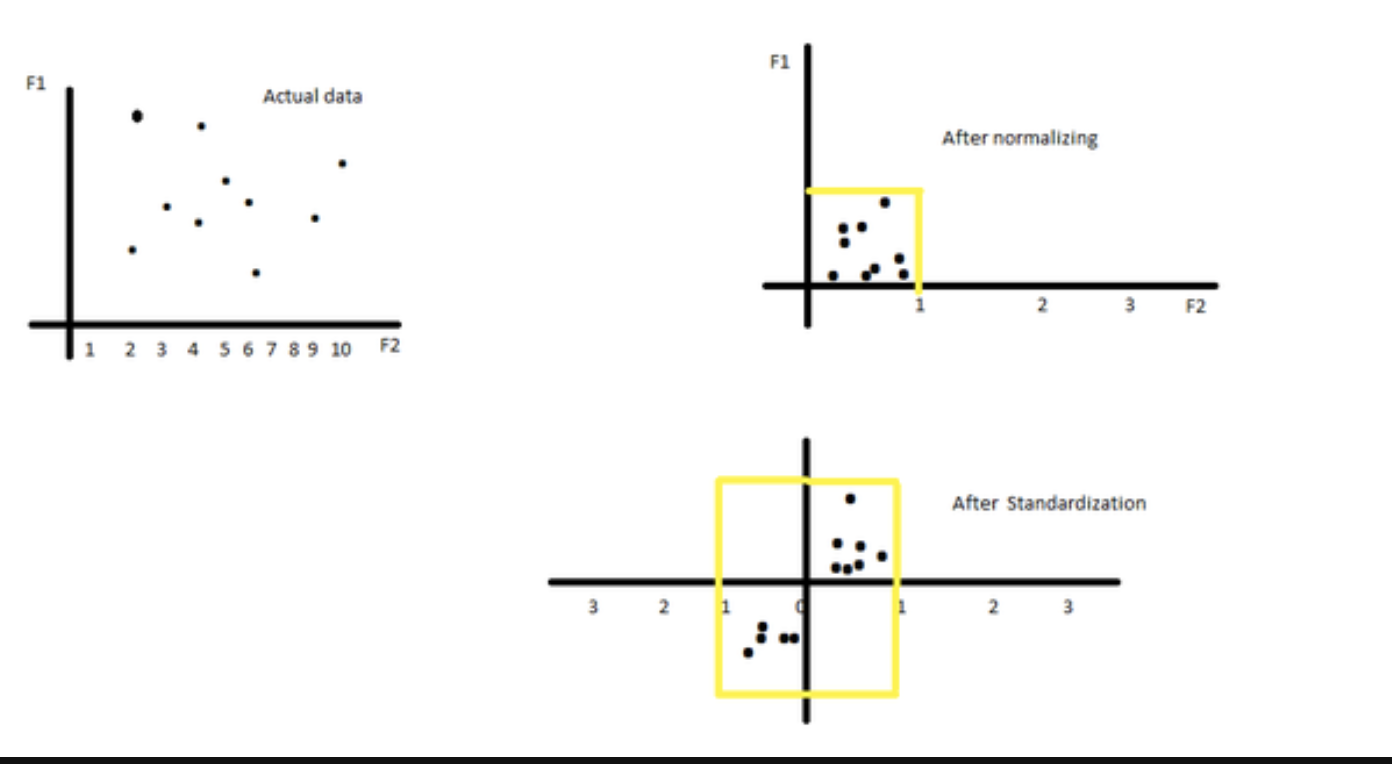

### <font color='skyblue'>Numerical Data [10 mins]</font>

We have seen how to handle categorical features. Now, let's see how to handle numerical features.

We use normalization techniques to bring numerical features to the same scale, preventing dominance of certain features due to larger values.

Here, we study two techniques to normalize the data.

<font color='lightgreen'>**Standardization:**</font>

- **Standardization** transforms features to have zero mean and unit variance. It centres data around the mean and scales it to have a variance of 1.
- Column standardization is often called mean centring and variance scaling.
- $X_{new}$ = $\frac{(x - mean(x))}{std(x)}$

#### <font color='violet'>Standard Scaler</font>

The `StandardScaler()` from the sklearn library normalizes data, ensuring the **mean** is zero and the **standard** **deviation** is 1, without altering the original distribution shape.

In [ ]:
num.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,TotalIncome,Loan_Amount_per_year,EMI
0,5849,0.0,128.0,30.0,5849.0,4.383333,365.277778
1,4583,1508.0,128.0,30.0,6091.0,4.266667,355.555556
2,3000,0.0,66.0,30.0,3000.0,2.200000,183.333333
3,2583,2358.0,120.0,30.0,4941.0,4.000000,333.333333
4,6000,0.0,141.0,30.0,6000.0,4.700000,391.666667


Let's check for one variable.

Check the minimum and maximum values of the LoanAmount.

In [ ]:
# calculate the minimum and maximum values of the variable
print(" The minimum value of the LoanAmount:",df_iqr['LoanAmount'].min(),"\n",
      "The maximum value of the LoanAmount:", df_iqr['LoanAmount'].max())

 The minimum value of the LoanAmount: 9.0 
 The maximum value of the LoanAmount: 260.0


Standardize the variable to reduce the scale of the data.

In [ ]:
# import StandardScaler
from sklearn.preprocessing import StandardScaler

# instantiate the standardscaler
standard_scale = StandardScaler()

# fit the StandardScaler
num['Scaled_LoanAmount'] = standard_scale.fit_transform(num[['LoanAmount']])

# calculate the minimum and maximum values of the variable
print(" The minimum value of the sales:",num['Scaled_LoanAmount'].min(),"\n",
      "The maximum value of the sales:", num['Scaled_LoanAmount'].max())

 The minimum value of the sales: -2.7081096824702664 
 The maximum value of the sales: 2.979741979703463


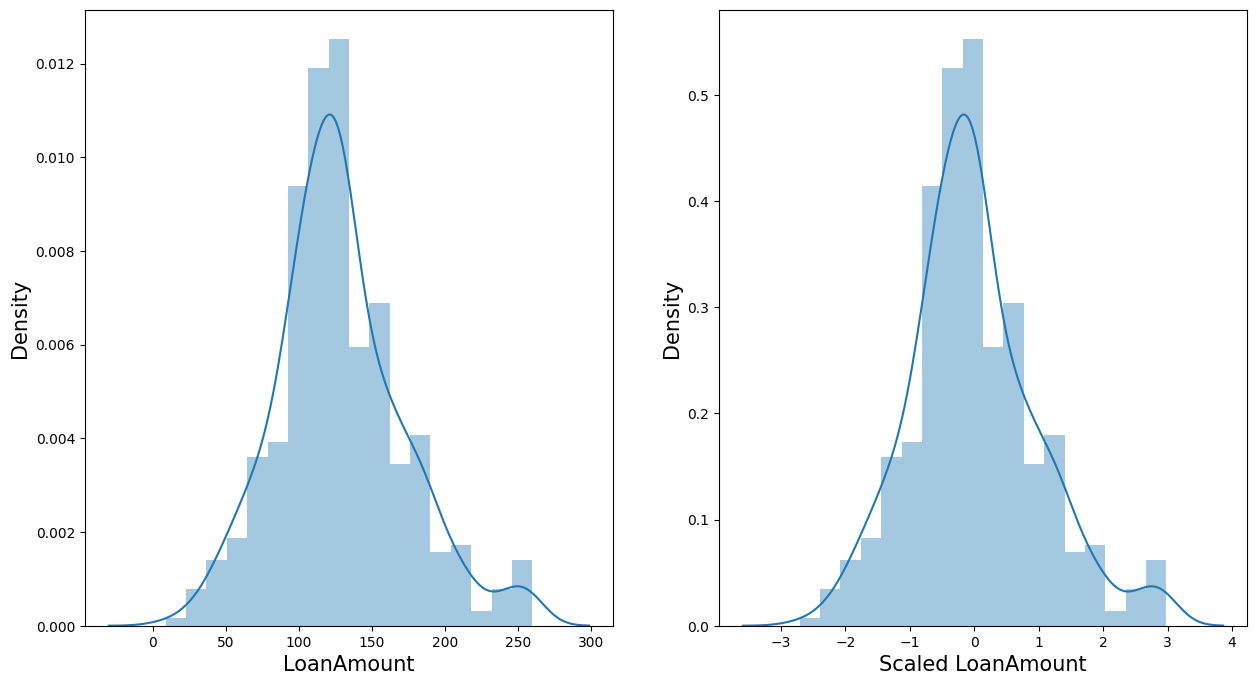

In [ ]:
# set the figure size
plt.rcParams["figure.figsize"] = [15,8]

# subplot is used to create a set of plots
# we create a subplot of 1 row by 2 columns
# use first column for plotting
plt.subplot(1,2,1)

# plot the distribution of the original variable
# axlabel: label the x-axis
sns.distplot(num['LoanAmount'])
# set label for the y-axis
plt.ylabel('Density', fontsize=15)
# set label for x-axis
plt.xlabel('LoanAmount', fontsize=15)

# We create a subplot of 1 row by 2 columns
# use the second column for plotting
plt.subplot(1,2,2)

# plot the distribution of the scaled variable
# axlabel: label the x-axis
sns.distplot(num['Scaled_LoanAmount'])
# set label for the y-axis
plt.ylabel('Density', fontsize=15)
# set label for the x-axis
plt.xlabel('Scaled LoanAmount', fontsize=15)
# display the plot
plt.show()

Here you can see from the above plots that there is only a change in the x-axis range. But there is no change in the distribution.

In [ ]:
# check the mean and standard deviation of the scaled variable
print("The mean of the scaled variable:", num['Scaled_LoanAmount'].mean(),"\n",
      "The standard deviation of the scaled variable:", num['Scaled_LoanAmount'].std())

The mean of the scaled variable: 1.2023375987206936e-16 
 The standard deviation of the scaled variable: 1.0010934940391132


#### <font color='violet'>Min-Max Normalization [10 mins]</font>

<font color='lightgreen'>**Normalization:**</font>

- Normalization ensures variables are comparable by scaling them to a standard range.
- Converts values between $[0, 1]$.
- $x_{normalized}$ = $\frac{(x — x_{min})}{(x_{max} — x_{min})}$

Min-max normalization is another method to normalize the data.

Transforms data linearly to fit within the specified range.

To perform this normalization, use the 'MinMaxScaler' from the sklearn library.

In [ ]:
# import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

# instantiate the MinMaxScaler
min_max = MinMaxScaler()

# fit the MinMaxScaler
num['minmax_LoanAmount'] = min_max.fit_transform(num[['LoanAmount']])

# minimum and maximum value of the normalized variable
num['minmax_LoanAmount'].min(), num['minmax_LoanAmount'].max()

(0.0, 1.0)

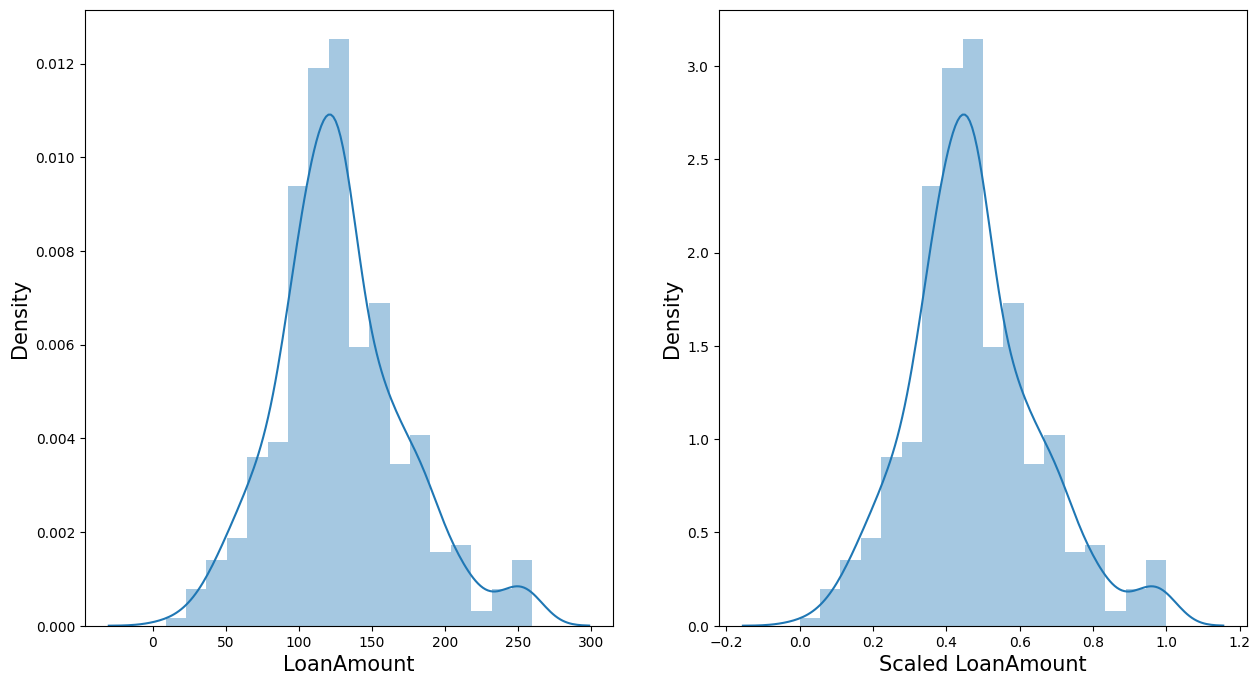

In [ ]:
# set the figure size
plt.rcParams["figure.figsize"] = [15,8]

# subplot is used to create a set of plots
# We create a subplot of 1 row by 2 columns
# use the first column for plotting
plt.subplot(1,2,1)

# plot the distribution of the original variable
# axlabel: label the x-axis
sns.distplot(num['LoanAmount'], axlabel='LoanAmount')
# set label for the y-axis
plt.ylabel('Density', fontsize=15)
# set label for the x-axis
plt.xlabel('LoanAmount', fontsize=15)

# we create a subplot of 1 row by 2 columns
# use the second column for plotting
plt.subplot(1,2,2)

# plot the distribution of the scaled variable
# axlabel: label the x-axis
sns.distplot(num['minmax_LoanAmount'], axlabel='Scaled LoanAmount')
# set label for the y-axis
plt.ylabel('Density', fontsize=15)
# set label for the x-axis
plt.xlabel('Scaled LoanAmount', fontsize=15)

# display the plot
plt.show()

<font color='violet'>**When to use Normalization and Standardisation?**</font>

- **Normalization** is good to use when you know that the distribution of your data **does not follow a Gaussian distribution**.
- **Standardization**, on the other hand, can be helpful in cases where the data **follows a Gaussian distribution**.

However, this does not have to be necessarily true. Also, unlike normalization, standardization does not have a bounding range.

So, even if you have outliers in your data, they will not be affected by standardization.

However, at the end of the day, the choice of using normalization or standardization will depend on your problem and the machine learning algorithm you are using.

There is no hard and fast rule to tell you when to normalize or standardize your data.

You can always start by fitting your model to raw, normalized and standardized data and compare the performance for best results.

To convert the complete data let's first perform the shapiro test to check the normality of the data.

In [ ]:
import scipy
from scipy.stats import shapiro
# Normality test

In [ ]:
num.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,TotalIncome,Loan_Amount_per_year,EMI,Scaled_LoanAmount,minmax_LoanAmount
0,5849,0.0,128.0,30.0,5849.0,4.383333,365.277778,-0.011479,0.474104
1,4583,1508.0,128.0,30.0,6091.0,4.266667,355.555556,-0.011479,0.474104
2,3000,0.0,66.0,30.0,3000.0,2.200000,183.333333,-1.416446,0.227092
3,2583,2358.0,120.0,30.0,4941.0,4.000000,333.333333,-0.192765,0.442231
4,6000,0.0,141.0,30.0,6000.0,4.700000,391.666667,0.283111,0.525896


In [ ]:
num.drop(['Scaled_LoanAmount','minmax_LoanAmount'],axis=1,inplace=True)
for i in num.columns:
    print('Column',i,':',shapiro(num[i]))

Column ApplicantIncome : ShapiroResult(statistic=np.float64(0.9215287708204641), pvalue=np.float64(1.0194749031910956e-14))
Column CoapplicantIncome : ShapiroResult(statistic=np.float64(0.8516965530524995), pvalue=np.float64(2.3174147300651245e-20))
Column LoanAmount : ShapiroResult(statistic=np.float64(0.9753212885449623), pvalue=np.float64(5.346698710419568e-07))
Column Loan_Amount_Term : ShapiroResult(statistic=np.float64(1.0), pvalue=np.float64(1.0))
Column TotalIncome : ShapiroResult(statistic=np.float64(0.9550975553022599), pvalue=np.float64(1.381294243141998e-10))
Column Loan_Amount_per_year : ShapiroResult(statistic=np.float64(0.9740893956115726), pvalue=np.float64(2.9408826583310763e-07))
Column EMI : ShapiroResult(statistic=np.float64(0.9740893956115724), pvalue=np.float64(2.9408826583307677e-07))


Since all the columns are not normally distributed we can use **minmax normalization** to scale the data.

In [ ]:
mm = MinMaxScaler()
mmsfit = mm.fit(num)
df_scaled = pd.DataFrame(mm.fit_transform(num),columns=num.columns)
df_scaled.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,TotalIncome,Loan_Amount_per_year,EMI
0,0.570528,0.000000,0.474104,0.0,0.414153,0.488048,0.488048
1,0.443788,0.268089,0.474104,0.0,0.436895,0.474104,0.474104
2,0.285314,0.000000,0.227092,0.0,0.146415,0.227092,0.227092
3,0.243568,0.419200,0.442231,0.0,0.328822,0.442231,0.442231
4,0.585644,0.000000,0.525896,0.0,0.428343,0.525896,0.525896


---

# Quiz-3 [5 mins]

```
You're working with a dataset where the 'Height' feature is measured in centimetres and the 'Weight' feature is measured in kilograms.
You decide to standardize the data.
What will be the mean and standard deviation of 'Height' after standardization?
```

**Options:**

- [ ] Mean = 0, Standard Deviation = 100
- [ ] Mean = 0, Standard Deviation = 1
- [ ] Mean = 50, Standard Deviation = 10
- [ ] Mean = 1, Standard Deviation = 0

<details>
**Explanation:**

- [ ] Mean = 0, Standard Deviation = 100
- [x] Mean = 0, Standard Deviation = 1
- [ ] Mean = 50, Standard Deviation = 10
- [ ] Mean = 1, Standard Deviation = 0

- Standardization, also known as z-score transformation, involves transforming data to have a mean of 0 and a standard deviation of 1.

- This standardization allows data from different scales to be compared more easily and is a common practice in data preprocessing.
- So, after standardization, the mean of 'Height' will become 0, and the standard deviation will become 1.
</details>

---

<font color="violet">Is Feature Scaling a substitute for Outlier Treatment?</font>

No.

While feature scaling can make algorithms more robust to differences in scale, it doesn't handle outliers.

It primarily focuses on adjusting the scale or range of feature values.

For instance
- In Min Max Scaler,
  - It scales the values to a specific range, often [0, 1].
  - While extreme values will be brought closer to the range, they still exist within it.
  - Further, it would directly impact the value of `x_max` and `x_min`
- In Standardization
  - It transforms values to have a mean of 0 and a standard deviation of 1.
  - Outliers may still have a substantial impact on the standard deviation.

In fact, both StandardScaler and MinMaxScaler are very sensitive to the presence of outliers.

They cannot guarantee balanced feature scales in the presence of outliers.

For addressing outliers, additional techniques may be employed, such as:

- Capping extreme values to a specified percentile.
- Applying mathematical transformations like log or square root to make the distribution more symmetric.
- Removing data points that are identified as outliers based on certain criteria.

### <font color='skyblue'>Conclusion and Q&A</font>

1. Missing Values
2. Outlier Treatment
3. Categorical to Numerical
4. Normalisation
5. Standardization

---

### <font color='violet'>Practice Question [10 mins] </span>

You can pick the following question and solve it during the lecture itself.

This will help the learners to get familiar with the problem solving process and motivate them to solve the assignments.

<font color='red'>**Make sure to start the doubt session before you start solving the question.**</font>

> Q: https://www.scaler.com/hire/test/problem/91066/ - Standardizing Age & Salary - Normalisation & standardization - Easy

---